# Coin Counter Demo: Calculating Total Value from Coin Images

## Problem Description

This notebook shows how to count coins in an image and calculate their total value. The main steps are:

1. Find where the coins are in the image
2. Separate each coin from the others
3. Figure out which coin is which (5, 10, or 25 centavos)
4. Add up the total value

The approach uses image processing techniques and classifies coins based on their size (bigger coins have higher values).

## Importing libraries

In [4]:
import os
import requests
import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

## Step 1: Getting the images

First we download the coin images from the course repository. 

Simple function that downloads an image

In [5]:
def download_image(url: str) -> str:
    filename = os.path.basename(url)
    
    if os.path.exists(filename):
        return filename
    
    response = requests.get(url)
    
    with open(filename, mode="wb") as file:
        file.write(response.content)
    
    return filename

Here we download three coin images:

In [6]:
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []
for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)
    
print(f"Downloaded {len(filenames)} images: {filenames}")

Downloaded 3 images: ['75.jpg', '80.jpg', '95.jpg']


Show the downloaded images:

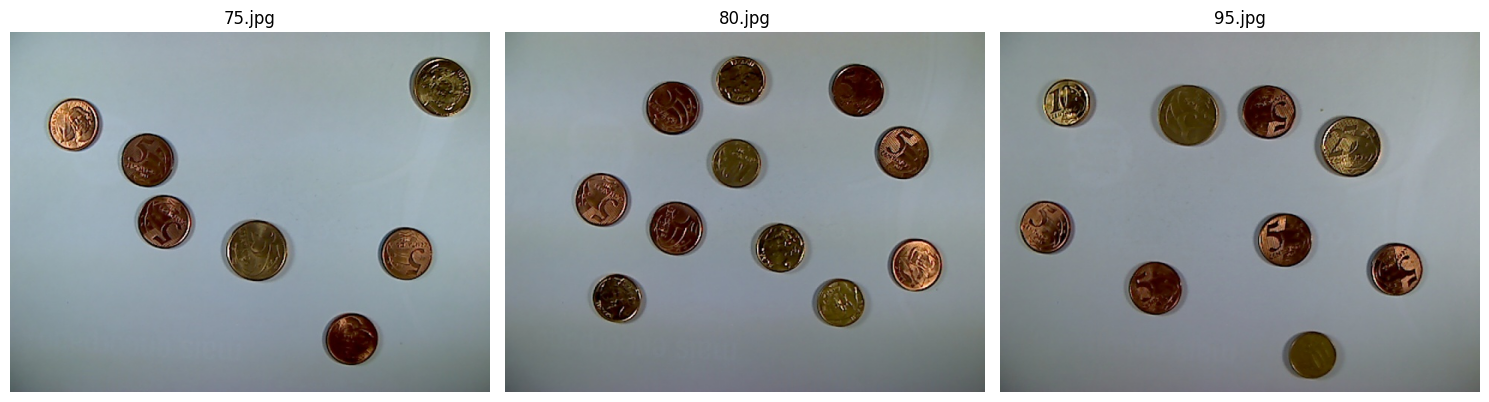

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

for i, file in enumerate(filenames):
    plt.subplot(1, 3, 1 + i)
    plt.axis("off")
    plt.title(file)
    img = mpimg.imread(file)
    plt.imshow(img)

plt.tight_layout()
plt.show()

## Step 2: Converting to grayscale

The original images are in color (RGB) but we don't really need the color information in this case where there are no coins of different value with the same size. Working with grayscale makes things simpler.

Here we convert to grayscale using a weighted formula:

**Gray = 0.3 × Red + 0.59 × Green + 0.11 × Blue**

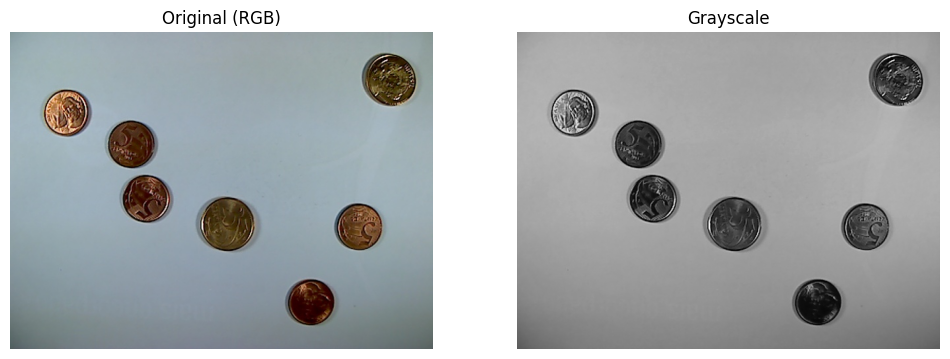

In [8]:
example_img = mpimg.imread(filenames[0]).astype('uint8')

# img[:,:,0] is Red, img[:,:,1] is Green, img[:,:,2] is Blue
example_gray = np.uint8(0.3 * example_img[:, :, 0] + 
                        0.59 * example_img[:, :, 1] + 
                        0.11 * example_img[:, :, 2])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(example_img)
plt.title('Original (RGB)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(example_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.show()

## Step 3: Segmentation and morphological operations

Now we need to separate the coins from the background (segmentation).

The function below does three things:

1. **Thresholding**: Converts the grayscale image to binary (black and white). This separates coins from the background.
2. **Closing**: Fills small holes inside the coins.
3. **Opening**: Removes small noise and separates coins that are touching.

### Thresholding

Thresholding works by choosing a value. Pixels above that value become white, pixels below become black. 

Here we use **Otsu's method** (`cv2.THRESH_OTSU`) which automatically finds the best threshold value. We also invert the image first (255 - img) because in the original the coins are brighter than the background, but we want the coins to be white in the binary image.

### Morphological operations

**Closing** fills holes. **Opening** removes noise and separates things that are touching.

Bigger kernels have stronger effects. Here we use:
- k_cl = 15 (for closing)
- k_op = 31 (for opening)

These values were found by trial and error until the results looked good.

In [9]:
def seg_and_postprocessing(img, k_cl, k_op):
    # Threshold to get binary image (inverting so coins become white)
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    
    # Create kernels for morphological operations
    kernel_cl = np.ones((k_cl, k_cl), np.uint8)
    kernel_op = np.ones((k_op, k_op), np.uint8)
    
    # Apply closing to fill small holes
    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)
    
    # Apply opening to remove noise and separate touching coins
    opened = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)
    
    # Show the three stages
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 3, 1)
    plt.imshow(binr, cmap="gray")
    plt.title('After Thresholding')
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(close, cmap="gray")
    plt.title('After Closing')
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(opened, cmap="gray")
    plt.title('After Opening (Final)')
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()
    
    return opened

Here we can test the function:

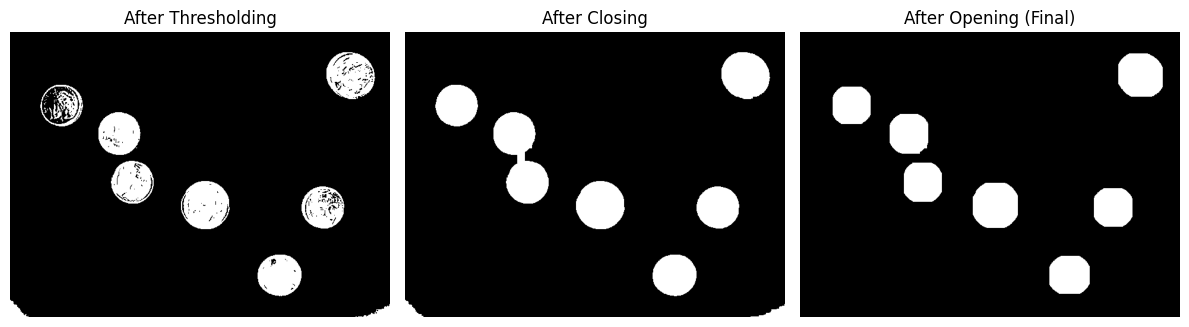

In [10]:
# Apply segmentation and cleaning
example_seg = seg_and_postprocessing(example_gray, k_cl=15, k_op=31)

## Step 4: Finding individual coins

Now that we have a clean binary image, we need to identify each coin. This step is known as connected component analysis.

Pixels that are touching belong to the same object. OpenCV has the function `cv2.connectedComponentsWithStats` that helps to do this.

The function returns:
- output[0]: number of components (including background)
- output[1]: labeled image where each component has a different number
- output[2]: statistics about each component
- output[3]: centroids (center points) of each component

The parameter 4 means 4-connectivity (only horizontal and vertical neighbors, not diagonal).

Number of components found: 8
(Background included, so actual coins = 7)


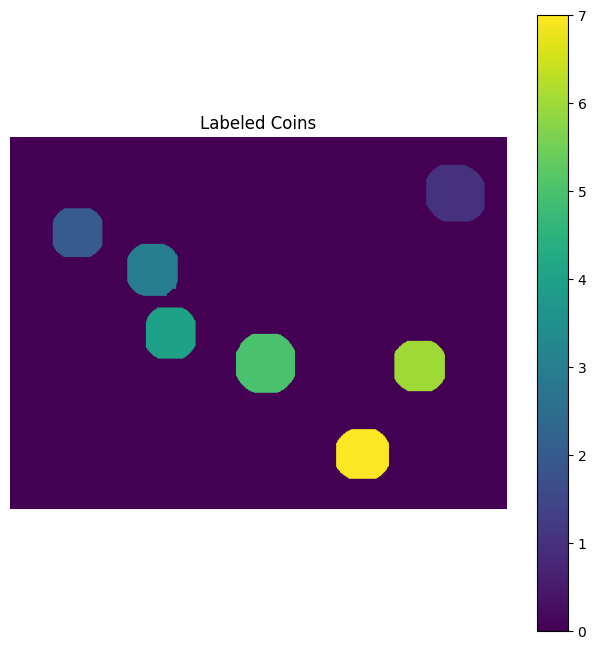

In [11]:
output = cv2.connectedComponentsWithStats(example_seg, 4)

print(f"Number of components found: {output[0]}")
print(f"(Background included, so actual coins = {output[0] - 1})")

plt.figure(figsize=(8, 8))
plt.imshow(output[1])
plt.title('Labeled Coins')
plt.axis('off')
plt.colorbar()
plt.show()

## Step 5: Measuring coin sizes

To figure out which coin is which, we measure the size of each coin. Bigger coins should have higher values.

Here's a function that counts how many pixels belong to each coin (the area).

In [12]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    
    for v in range(n_labels - 1):
        npixels = (img[img == v + 1] // (v + 1)).sum()
        list_npixels.append(npixels)
    
    return list_npixels

Here we can see the coin sizes:

In [13]:
coin_sizes = calc_npixels_label(output[1], output[0])

print("Size of each coin (in pixels):")
for i, size in enumerate(coin_sizes, 1):
    print(f"  Coin {i}: {size} pixels")

Size of each coin (in pixels):
  Coin 1: 4805 pixels
  Coin 2: 3638 pixels
  Coin 3: 3867 pixels
  Coin 4: 3786 pixels
  Coin 5: 5016 pixels
  Coin 6: 3767 pixels
  Coin 7: 3861 pixels


## Step 6: Classifying coins by size

Now the logic to classify each coin. Based on the sizes observed, these are the rules:

- If size < 3500 pixels: 10 centavos
- If size > 4600 pixels: 25 centavos  
- Otherwise (3500 to 4600): 5 centavos

These threshold values (3500 and 4600) were found by looking at the sizes and choosing values that separate the three types.

Note: This works for these specific images (taken at the same distance) but it will  need adjustment for cases of different images or resolutions.

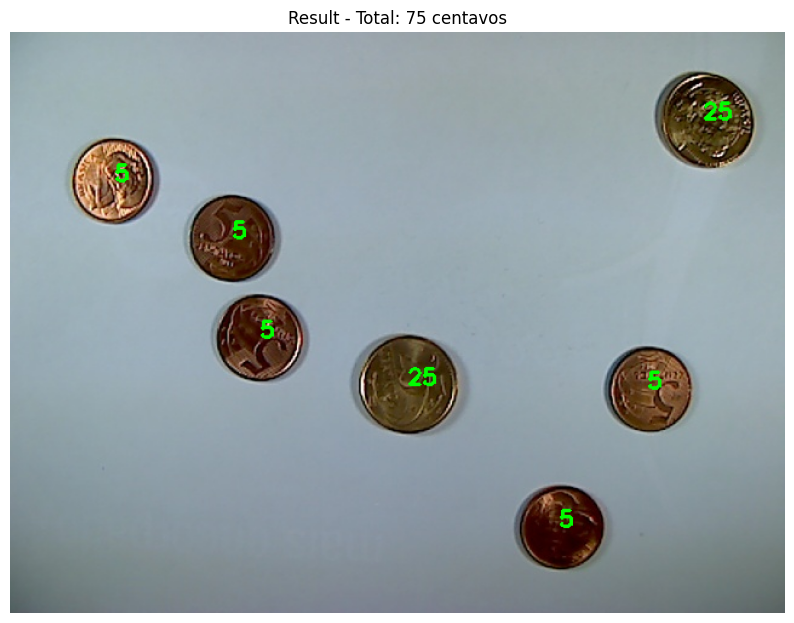


Number of coins: 7
Total value: 75 centavos


In [14]:
example_result = example_img.copy()
total_value = 0

for n, pixels in enumerate(coin_sizes):
    # Get the position (centroid) to write the value on the image
    x = int(output[3][n + 1][0])
    y = int(output[3][n + 1][1])
    
    # Classify based on size
    if pixels < 3500:
        value = 10
    elif pixels > 4600:
        value = 25
    else:
        value = 5
    
    total_value += value
    
    # Write the value on the image
    cv2.putText(example_result, str(value), (x, y), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(example_result)
plt.title(f'Result - Total: {total_value} centavos')
plt.axis('off')
plt.show()

print(f"\nNumber of coins: {len(coin_sizes)}")
print(f"Total value: {total_value} centavos")

## Step 7: Processing all images

Now we can put it all together and process the three coin images:


Processing: 75.jpg


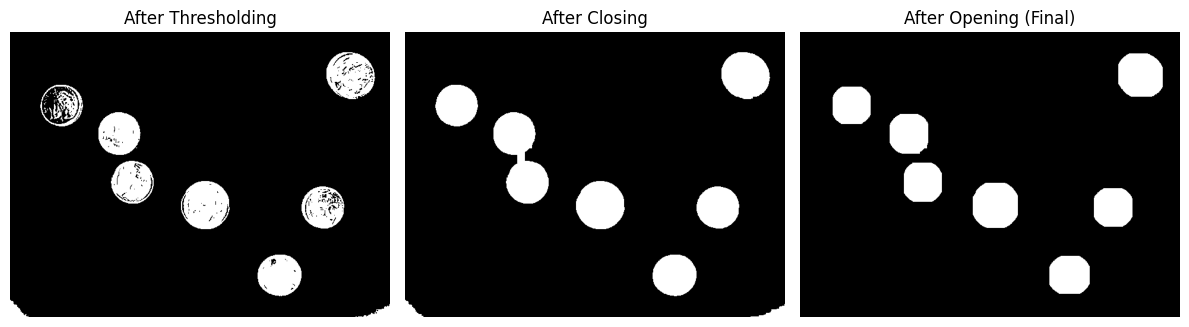

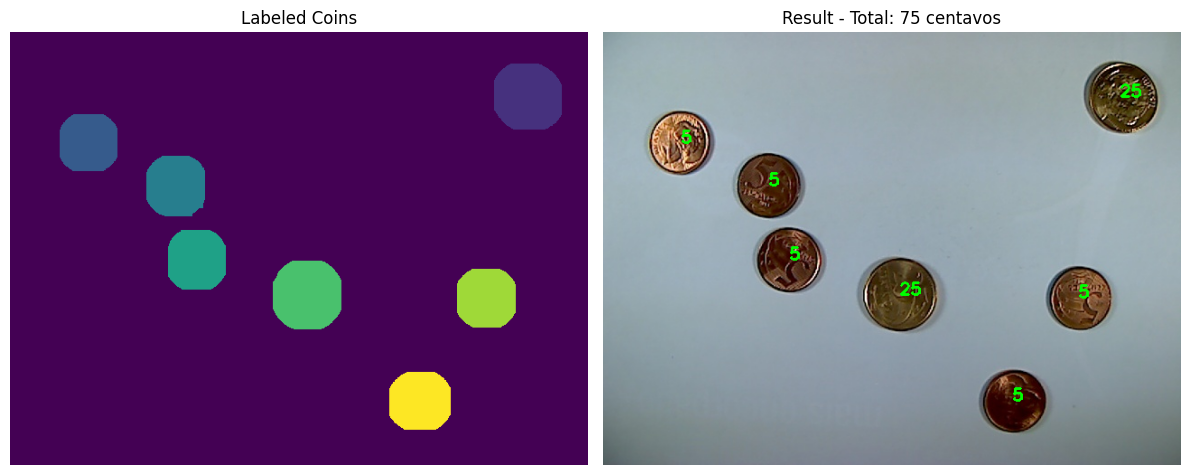


Number of coins: 7
Coin sizes (pixels): [np.int64(4805), np.int64(3638), np.int64(3867), np.int64(3786), np.int64(5016), np.int64(3767), np.int64(3861)]
Total value: 75 centavos

Processing: 80.jpg


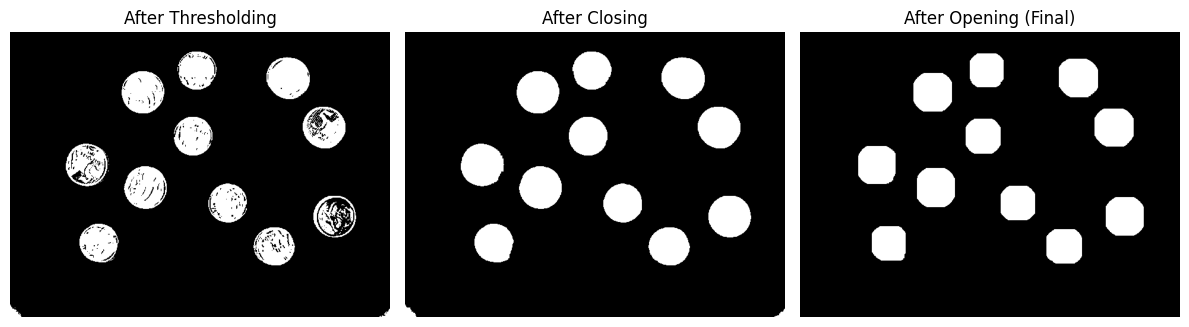

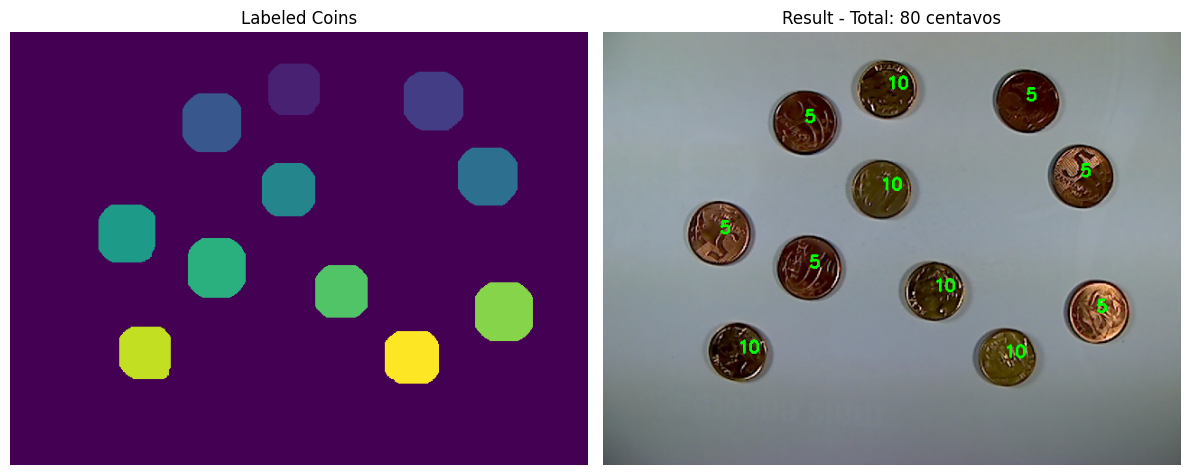


Number of coins: 11
Coin sizes (pixels): [np.int64(2978), np.int64(3793), np.int64(3775), np.int64(3736), np.int64(3132), np.int64(3678), np.int64(3778), np.int64(3064), np.int64(3728), np.int64(3049), np.int64(3183)]
Total value: 80 centavos

Processing: 95.jpg


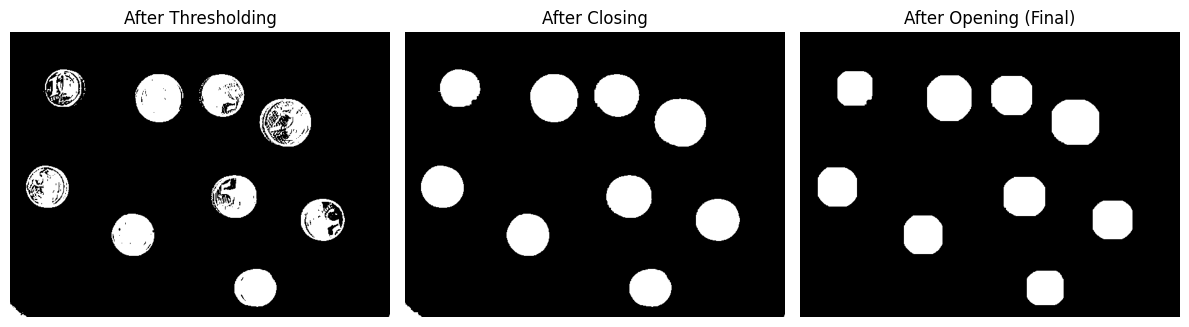

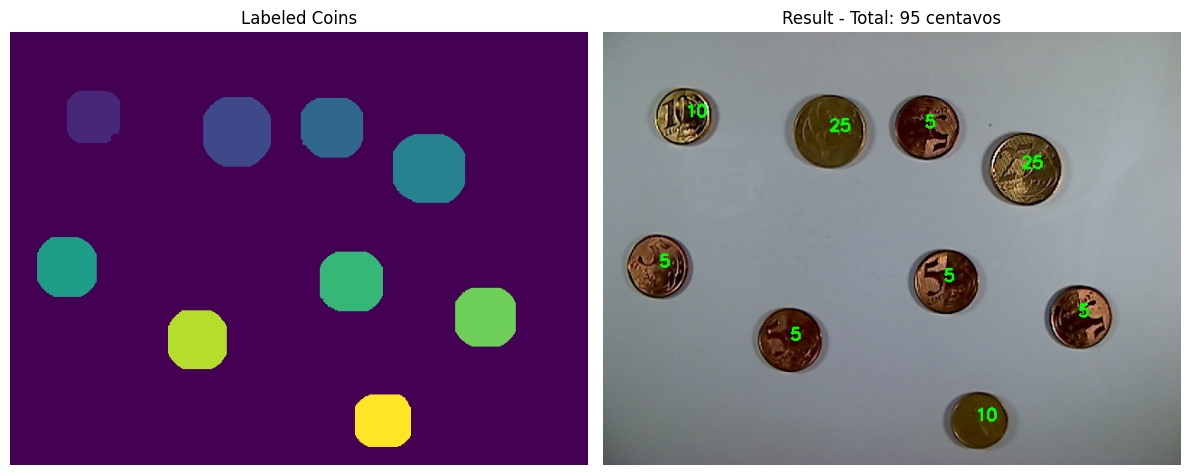


Number of coins: 9
Coin sizes (pixels): [np.int64(3114), np.int64(4997), np.int64(4017), np.int64(5335), np.int64(3845), np.int64(4113), np.int64(3897), np.int64(3766), np.int64(3285)]
Total value: 95 centavos


In [15]:
# Process each image
for i, file in enumerate(filenames):
    print(f"\n{'='*50}")
    print(f"Processing: {file}")
    print('='*50)
    
    # Step 1: Load and convert to grayscale
    img = mpimg.imread(file).astype('uint8')
    img_gray = np.uint8(0.3 * img[:, :, 0] + 
                        0.59 * img[:, :, 1] + 
                        0.11 * img[:, :, 2])
    
    # Step 2: Segment and clean up
    seg_img = seg_and_postprocessing(img_gray, k_cl=15, k_op=31)
    
    # Step 3: Find connected components
    output = cv2.connectedComponentsWithStats(seg_img, 4)
    
    # Step 4: Calculate sizes
    list_npixels = calc_npixels_label(output[1], output[0])
    
    # Step 5 & 6: Classify coins and calculate total
    total_value = 0
    for n, pixels in enumerate(list_npixels):
        x = int(output[3][n + 1][0])
        y = int(output[3][n + 1][1])
        
        if pixels < 3500:
            value = 10
        elif pixels > 4600:
            value = 25
        else:
            value = 5
        
        total_value += value
        cv2.putText(img, str(value), (x, y), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    # Show results
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(output[1])
    plt.title('Labeled Coins')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.title(f'Result - Total: {total_value} centavos')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nNumber of coins: {len(list_npixels)}")
    print(f"Coin sizes (pixels): {list_npixels}")
    print(f"Total value: {total_value} centavos")

### Limitations:

- Size thresholds (3500 and 4600) are specific to this dataset
- Assumes coins don't overlap
- Needs clear contrast between coins and background
- Only uses size for classification
- Kernel sizes (15 and 31) found by trial and error

## Useful references

- [OpenCV: Image Thresholding](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html) - Documentation on thresholding methods including Otsu's method
- [OpenCV: Morphological Transformations](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html) - Tutorial on morphological operations like closing and opening
- [OpenCV: Structural Analysis and Shape Descriptors](https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html) - Documentation for connectedComponentsWithStats function